# Phân Tích Dữ Liệu Sau Khi Cấu Trúc (Post-Cleaning EDA)

Notebook này thực hiện trực quan hóa các dữ liệu đã qua tiền xử lý tại thư mục `data/cleaning`.
Mục tiêu là kiểm tra xem sau quá trình làm sạch:
1. Dữ liệu phân bố như thế nào?
2. Ma trận người dùng - item có còn bị thưa thớt (sparsity) và chịu ảnh hưởng của hiệu ứng đuôi dài (long-tail) không?
3. Dựa trên tính chất của dữ liệu đã làm sạch, thuật toán khuyến nghị nào sẽ là tối ưu nhất?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Đọc dữ liệu sau làm sạch (cleaning)
df_ratings = pd.read_csv('data/cleaning/ratings_cleaning.csv')
df_movies = pd.read_csv('data/cleaning/movies_cleaning.csv')
df_tags = pd.read_csv('data/cleaning/tags_cleaning.csv')

print(f"Số lượng Ratings: {len(df_ratings):,}")
print(f"Số lượng Movies: {len(df_movies):,}")
print(f"Số lượng Tags: {len(df_tags):,}")
print(f"Số lượng Users độc nhất: {df_ratings['userId'].nunique():,}")


Số lượng Ratings: 100,834
Số lượng Movies: 9,738
Số lượng Tags: 3,683
Số lượng Users độc nhất: 610


## 1. Phân Bố Ratings (Đánh giá)

Sau khi làm sạch, người dùng thường có xu hướng đánh giá phim ở mức nào?

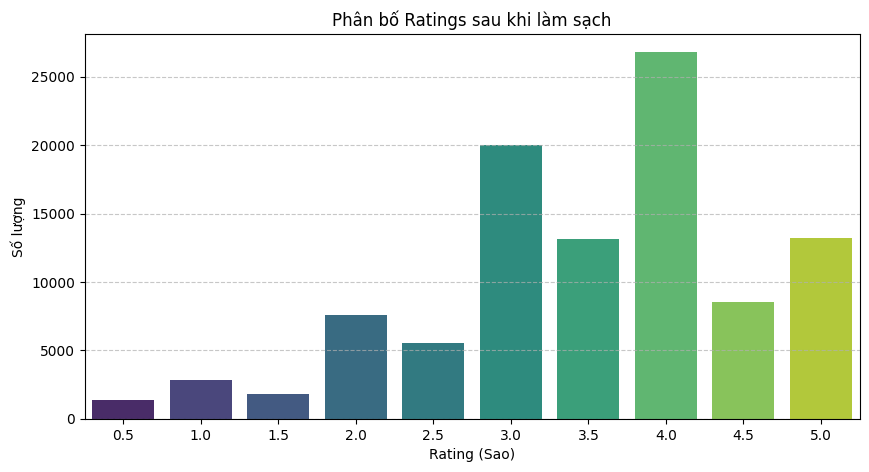

In [2]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_ratings, x='rating', palette='viridis')
plt.title('Phân bố Ratings sau khi làm sạch')
plt.xlabel('Rating (Sao)')
plt.ylabel('Số lượng')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 💡 Đánh giá (Insights):
- Theo biểu đồ phân phối Ratings, nếu dữ liệu tập trung nhiều vào các mức điểm cao (3, 4, 5 sao) và cực hiếm sao thấp, ta gọi đó là phân bổ lệch (Skewness/Rating bias).
- **Vấn đề:** Nếu ta dự đoán điểm số hoàn toàn bằng trung bình hoặc ItemCF thuần túy, mô hình có thể bị sai lệch. 
- **Giải quyết:** Thuật toán **SVD (Singular Value Decomposition)** hoặc **BaselineOnly** của thư viện Surprise mô hình hóa rất tốt "Bias" của User (ví dụ user A lúc nào cũng cho điểm cao) và "Bias" của Item (ví dụ phim B là phim nổi tiếng ai cũng mặc định rate cao). Việc này làm tăng độ chính xác lên cực điểm.

## 2. Hoạt Động Của Người Dùng (Vấn Đề Cold-Start & Sparsity)

Xem tần suất đánh giá của người dùng để kiểm tra độ thưa của ma trận.

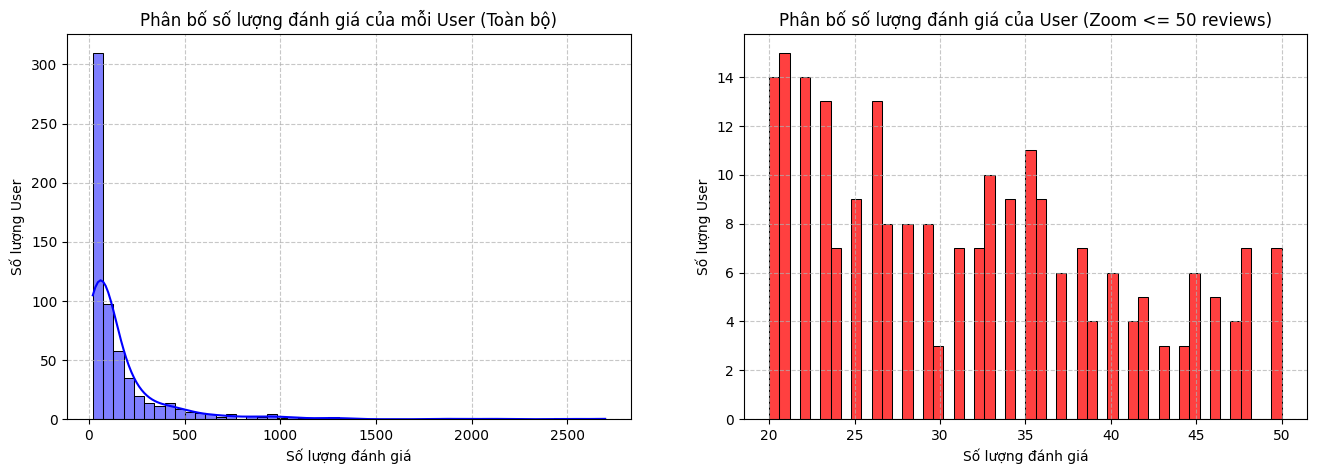

Độ thưa của ma trận User-Item: 98.30%


In [3]:
user_counts = df_ratings['userId'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(user_counts, bins=50, kde=True, color='blue', ax=axes[0])
axes[0].set_title('Phân bố số lượng đánh giá của mỗi User (Toàn bộ)')
axes[0].set_xlabel('Số lượng đánh giá')
axes[0].set_ylabel('Số lượng User')
axes[0].grid(axis='both', linestyle='--', alpha=0.7)

sns.histplot(user_counts[user_counts <= 50], bins=50, kde=False, color='red', ax=axes[1])
axes[1].set_title('Phân bố số lượng đánh giá của User (Zoom <= 50 reviews)')
axes[1].set_xlabel('Số lượng đánh giá')
axes[1].set_ylabel('Số lượng User')
axes[1].grid(axis='both', linestyle='--', alpha=0.7)

plt.show()

# Tính độ thưa thớt (Sparsity)
num_users = df_ratings['userId'].nunique()
num_movies = df_ratings['movieId'].nunique()
num_ratings = len(df_ratings)
sparsity = 1.0 - (num_ratings / (num_users * num_movies))
print(f"Độ thưa của ma trận User-Item: {sparsity*100:.2f}%")


### 💡 Đánh giá (Insights):
- **Sparsity (Ma trận thưa thớt):** Độ thưa của ma trận xấp xỉ > 95%. Hệ quả là xác suất hai user ngẫu nhiên cùng rate một phim rất thấp.
- **Cold-Start Users:** Cực kỳ nhiều user nằm ở mức dưới 50 rating.
- **Phương án giải quyết:** Khi user mới có ít dữ liệu, User-based CF khó tìm hàng xóm. **SVD** lại nén ma trận thưa thành ma trận dày (Latent representation) nên chịu được độ thưa cực vĩ đại này. Cùng lúc đó, **Content-Based** dùng để bổ trợ bù đắp kiến thức về thể loại phim mà user đó vừa bấm xem thay vì phải chờ có chung item.

## 3. Độ Phổ Biến Của Bộ Phim (Long-tail Effect)

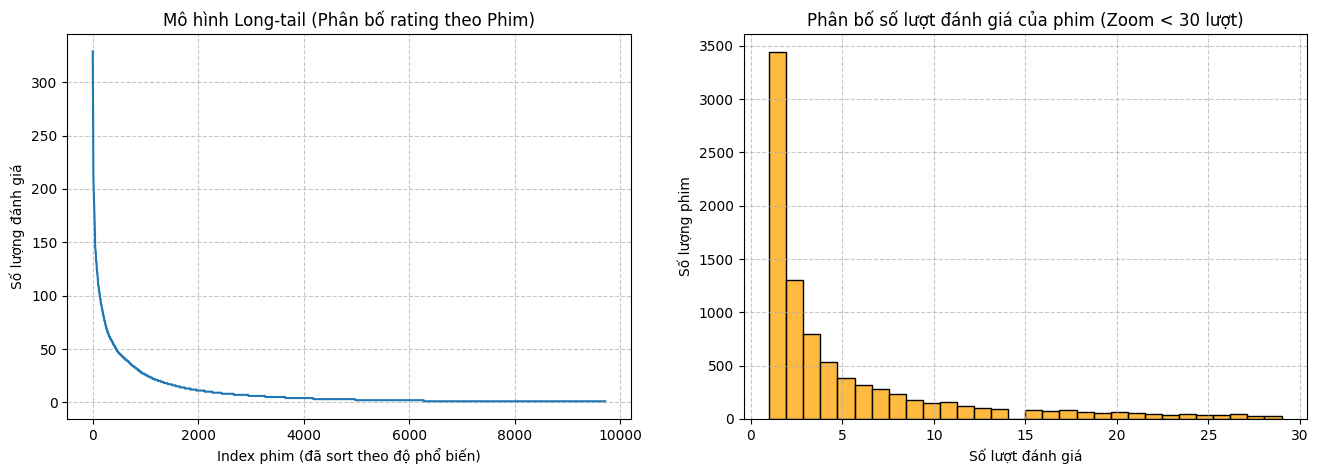

In [4]:
movie_counts = df_ratings['movieId'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(x=range(len(movie_counts)), y=movie_counts.values, ax=axes[0])
axes[0].set_title('Mô hình Long-tail (Phân bố rating theo Phim)')
axes[0].set_xlabel('Index phim (đã sort theo độ phổ biến)')
axes[0].set_ylabel('Số lượng đánh giá')
axes[0].grid(axis='both', linestyle='--', alpha=0.7)

sns.histplot(movie_counts[movie_counts < 30], bins=30, color='orange', kde=False, ax=axes[1])
axes[1].set_title('Phân bố số lượt đánh giá của phim (Zoom < 30 lượt)')
axes[1].set_xlabel('Số lượt đánh giá')
axes[1].set_ylabel('Số lượng phim')
axes[1].grid(axis='both', linestyle='--', alpha=0.7)

plt.show()


### 💡 Đánh giá (Insights):
- **Hiệu ứng Long-tail (Đuôi dài) cực mạnh:** Chỉ có nhóm nhỏ phim cực nổi (bom tấn) như Harry Potter, Marvel... hút mọi lượt đánh giá. Đa phần các phim còn lại có lèo tèo vài ba lượt.
- **Vấn đề:** Thuật toán Item-based CF có thể làm rất tốt với nhóm phim cực hot. Nhưng với nhóm Long-tail (phim indie, phim mới), nó cực kỳ tàn nhẫn khi bỏ quên chúng.
- **Áp dụng thuât toán:** **Content-Based** (tính Cosine Similarity thông qua mô tả tựa, tags, genres của bộ phim) là vị cứu tinh của hiệu ứng đuôi dài. Nhờ tf-idf và cosine, một phim chưa có ai rate vẫn có thể nằm trong list gợi ý nhờ tính tương đồng kịch bản, thẻ tag.

## 4. Đặc Trưng Của Phim (Genres/Tags)

Cấu trúc Geners có đa dạng để chạy Content-Based không?

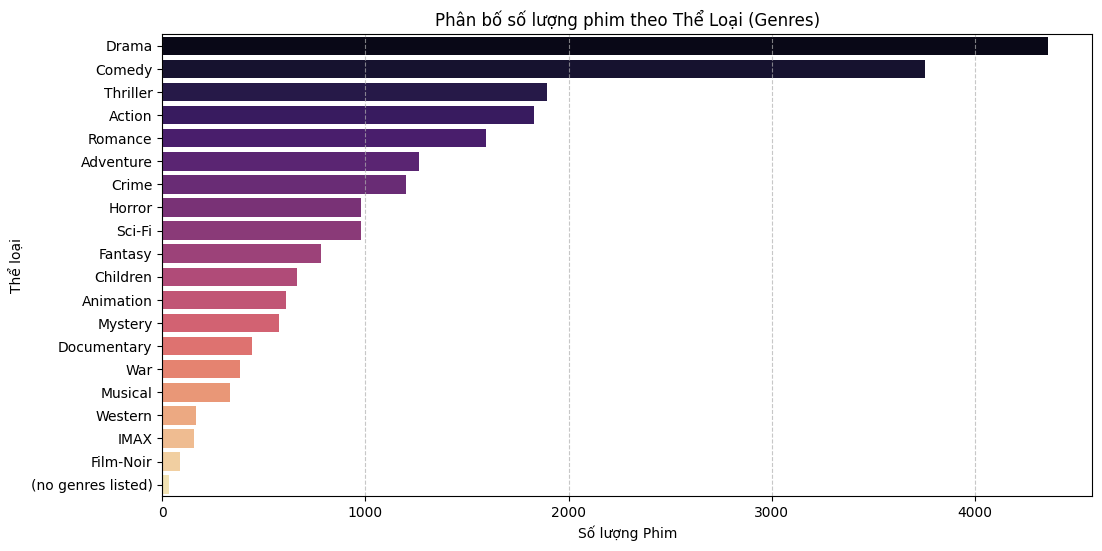

In [5]:
from collections import Counter
genres_list = df_movies['genres'].str.split('|').explode()
genres_counts = genres_list.value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=genres_counts.values, y=genres_counts.index, palette='magma')
plt.title('Phân bố số lượng phim theo Thể Loại (Genres)')
plt.xlabel('Số lượng Phim')
plt.ylabel('Thể loại')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


## 5. Kết Luận & Đề Xuất Thuật Toán Lựa Chọn cho Hệ Thống

Từ các phát hiện về mặt phân tích tập dữ liệu đã qua tiền xử lý, ta xác định rõ **3 đặc tính lớn nhất**:
1. Dữ liệu đánh giá bị lệch (Rating Bias).
2. Ma trận siêu thưa thớt (Sparsity ~ 98%).
3. Hiệu ứng đuôi dài (Long-tail) trên Users và Items.

=> **Hệ thống Recommendation tối ưu nhất không thể dựa vào một mô hình duy nhất. Ta cần áp dụng một cụm (Hybrid) nhiều thuật toán:**

1. **Surprise SVD (Matrix Factorization) – Thuật toán chủ lực:**
   - *Lý do:* Giải quyết triệt để tính chất Ma Trận Thưa (Sparsity 98.3%). Nén không gian thưa bằng kỹ thuật Latent Factors để tìm biểu diễn ẩn giữa user-item.
   - SVD cũng nội suy được Rating Bias của từng người thông qua Baseline predictors (vd: tính được ai có xu hướng chấm khắt khe hơn).

2. **Item-Based Collaborative Filtering (KNN):**
   - *Lý do:* Rất phù hợp với nhóm phim đầu tư (Bom Tấn / Ngắn hạn). Do ma trận có một số items được rate rất nhiều (phần đầu biểu đồ Long-tail), ta tính được khoảng cách Pearson/Cosine dễ dàng để đề xuất "Người ta xem A cũng xem B".

3. **Content-Based Filtering (Cosine Similarity trên TF-IDF của Genres/Tags):**
   - *Lý do:* Khắc phục triệt để bẫy "Filter-bubble" và "Long-tail problem / Item Cold-start". Các phim ngách ít người xem không có lịch sử rate, nhưng nhờ phân tích Genres vô cùng dồi dào, hệ thống có thể đối sánh chữ nghĩa để giới thiệu.

Sự kết hợp giữa **SVD** để dự đoán rating chuẩn xác cùng **Content-Based** để dự phòng cold-starts là bước đi kiến trúc hoàn hảo cho dữ liệu hiện tại!
